In [ ]:
#import libraries

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#load the data

DATA_PATH = Path("../data/raw/SeoulBikeData.csv")

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 8760
Columns: 14


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
#inspect column names

df.columns.tolist()

['Date',
 'Rented Bike Count',
 'Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday',
 'Functioning Day']

In [ ]:
#inspect data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [ ]:
#check missing values

df.isna().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [ ]:
#basic statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


Clean and explore the data

In [ ]:
#Rename columns

df = df.rename(
    columns={
        "Date": "date",
        "Rented Bike Count": "rented_bike_count",
        "Hour": "hour",
        "Temperature(°C)": "temperature",
        "Humidity(%)": "humidity",
        "Wind speed (m/s)": "wind_speed",
        "Visibility (10m)": "visibility",
        "Dew point temperature(°C)": "dew_point_temperature",
        "Solar Radiation (MJ/m2)": "solar_radiation",
        "Rainfall(mm)": "rainfall",
        "Snowfall (cm)": "snowfall",
        "Seasons": "season",
        "Holiday": "holiday",
        "Functioning Day": "functioning_day",
    }
)

df.columns.tolist()

['date',
 'rented_bike_count',
 'hour',
 'temperature',
 'humidity',
 'wind_speed',
 'visibility',
 'dew_point_temperature',
 'solar_radiation',
 'rainfall',
 'snowfall',
 'season',
 'holiday',
 'functioning_day']

In [ ]:
#Convert the date

df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")

df["timestamp"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")

df = df.sort_values("timestamp").reset_index(drop=True)

df[["date", "hour", "timestamp"]].head()

,date,hour,timestamp
0,2017-12-01,0,2017-12-01 00:00:00
1,2017-12-01,1,2017-12-01 01:00:00
2,2017-12-01,2,2017-12-01 02:00:00
3,2017-12-01,3,2017-12-01 03:00:00
4,2017-12-01,4,2017-12-01 04:00:00


In [ ]:
#Check the time range and duplicate observations

print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())
print("Duplicated timestamps:", df["timestamp"].duplicated().sum())

Start: 2017-12-01 00:00:00
End: 2018-11-30 23:00:00
Duplicated timestamps: 0


In [ ]:
#Inspect categorical values

for column in ["season", "holiday", "functioning_day"]:
    print(f"\n{column}:")
    print(df[column].value_counts())


season:
season
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

holiday:
holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

functioning_day:
functioning_day
Yes    8465
No      295
Name: count, dtype: int64


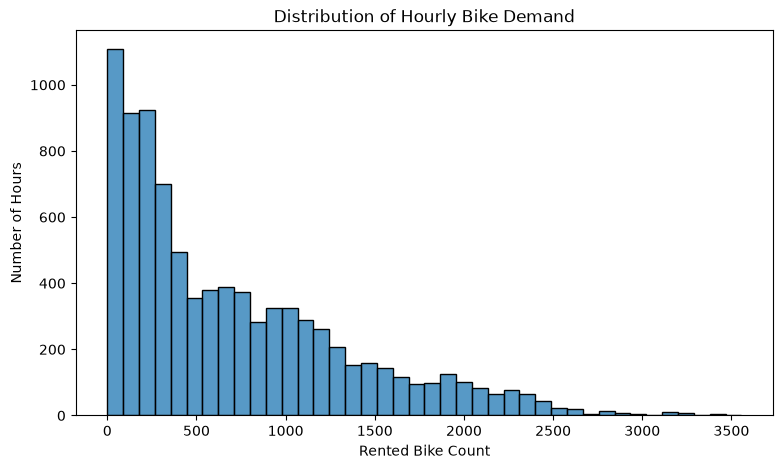

In [ ]:
#Plot the target distribution

plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="rented_bike_count", bins=40)

plt.title("Distribution of Hourly Bike Demand")
plt.xlabel("Rented Bike Count")
plt.ylabel("Number of Hours")
plt.show()

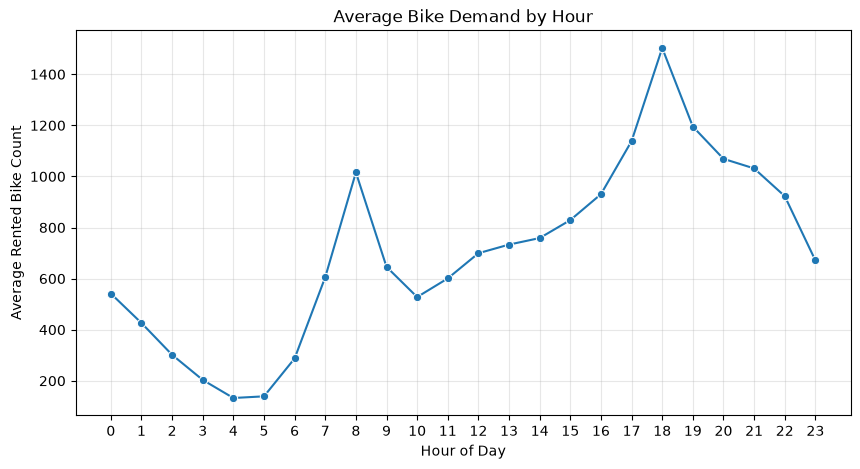

In [ ]:
#Plot average demand by hour

hourly_demand = (
    df.groupby("hour", as_index=False)["rented_bike_count"]
    .mean()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="rented_bike_count",
    marker="o",
)

plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

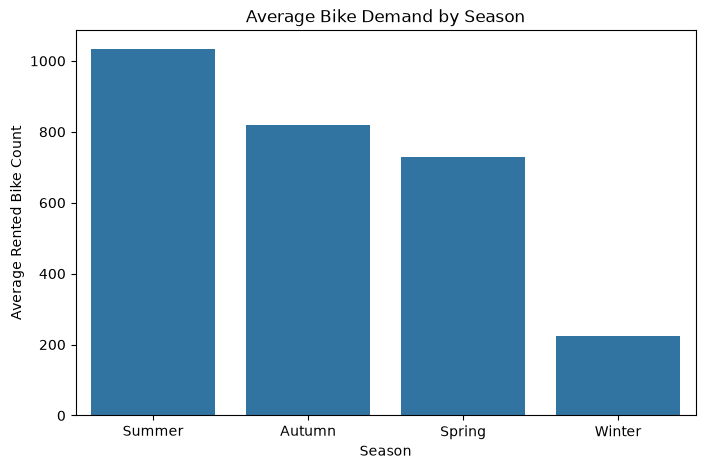

In [ ]:
#Plot average demand by season


seasonal_demand = (
    df.groupby("season", as_index=False)["rented_bike_count"]
    .mean()
    .sort_values("rented_bike_count", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_demand,
    x="season",
    y="rented_bike_count",
)

plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.show()


In [14]:
df.groupby("functioning_day")["rented_bike_count"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
functioning_day,,,,
No,295,0.000000,0,0
Yes,8465,729.156999,2,3556
